In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

from sklearn.metrics import mean_absolute_error, mean_squared_error


In [14]:
df = pd.read_csv("datasetfinal.csv")

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.asfreq('MS')

ts = df['wisatawan']


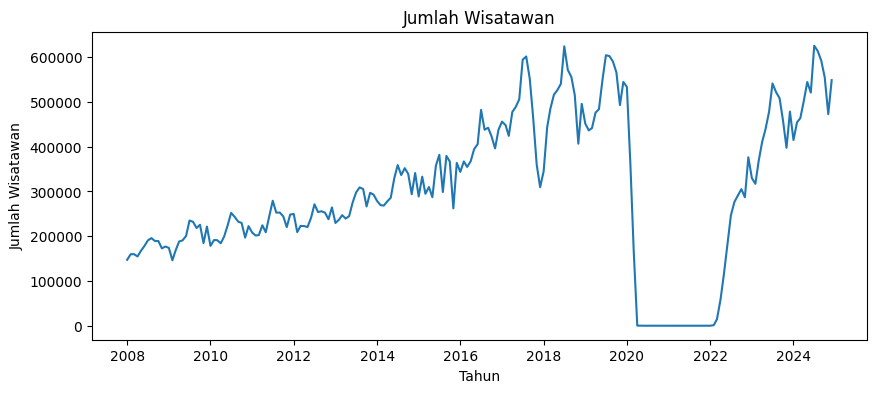

In [15]:
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.title("Jumlah Wisatawan")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Wisatawan")
plt.show()


In [16]:
adf_result = adfuller(ts.dropna())

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])


ADF Statistic : -2.6198203772362443
p-value       : 0.08896959881225519


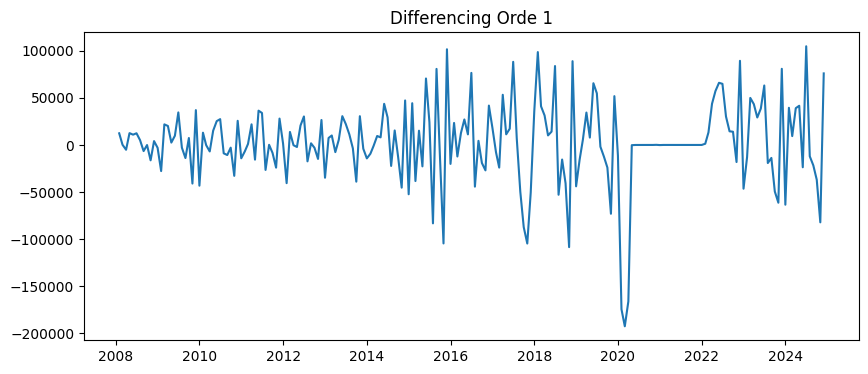

In [17]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(ts_diff)
plt.title("Differencing Orde 1")
plt.show()


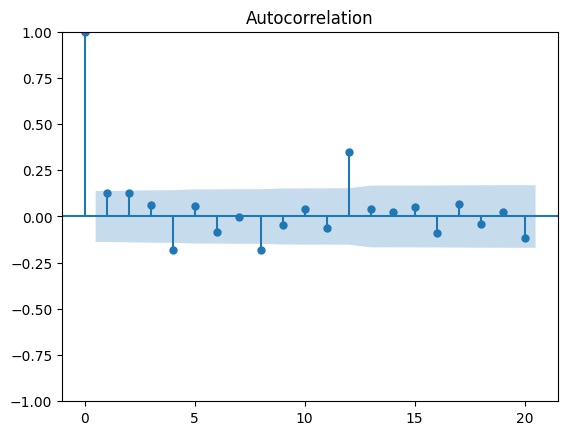

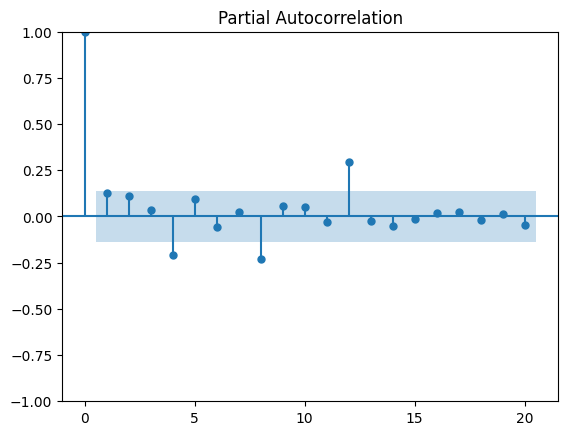

In [18]:
plot_acf(ts_diff, lags=20)
plt.show()

plot_pacf(ts_diff, lags=20)
plt.show()


In [19]:
model = sm.tsa.ARIMA(ts, order=(1,1,1))
result = model.fit()

print(result.summary())


                               SARIMAX Results                                
Dep. Variable:              wisatawan   No. Observations:                  204
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2452.046
Date:                Wed, 17 Dec 2025   AIC                           4910.092
Time:                        19:53:09   BIC                           4920.032
Sample:                    01-01-2008   HQIC                          4914.113
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4870      0.378      1.289      0.197      -0.253       1.227
ma.L1         -0.3561      0.396     -0.900      0.368      -1.132       0.420
sigma2      1.843e+09   3.88e-11   4.75e+19      0.0

In [20]:
pred_in = result.predict(start=1, end=len(ts)-1, typ='levels')
actual = ts[1:]


In [21]:
# Filter data yang bernilai 0
mask = actual != 0

mae = mean_absolute_error(actual, pred_in)
rmse = np.sqrt(mean_squared_error(actual, pred_in))

mape = np.mean(
    np.abs((actual[mask] - pred_in[mask]) / actual[mask])
) * 100

accuracy = 100 - mape


In [22]:
print("Evaluasi Model ARIMA")
print("-"*40)
print(f"MAE      : {mae:,.2f}")
print(f"RMSE     : {rmse:,.2f}")
print(f"MAPE     : {mape:.2f}%")
print(f"Akurasi  : {accuracy:.2f}%")


Evaluasi Model ARIMA
----------------------------------------
MAE      : 29,346.06
RMSE     : 42,618.58
MAPE     : 1661.50%
Akurasi  : -1561.50%


In [23]:
forecast = result.get_forecast(steps=12)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()


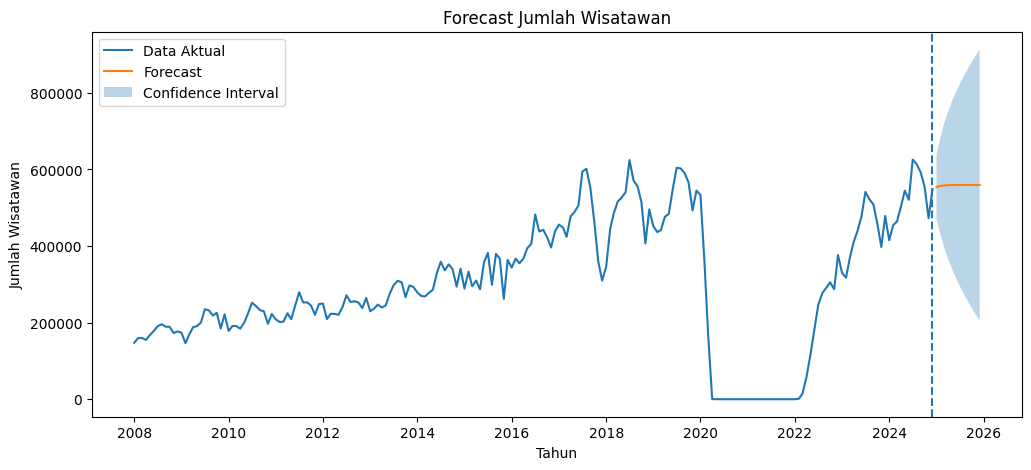

In [24]:
plt.figure(figsize=(12,5))

plt.plot(ts, label="Data Aktual")
plt.axvline(ts.index[-1], linestyle="--")
plt.plot(mean_forecast, label="Forecast")

plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label="Confidence Interval"
)

plt.legend()
plt.title("Forecast Jumlah Wisatawan")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Wisatawan")
plt.show()


In [25]:
import pickle

with open("model_arima_wisman2.pkl", "wb") as f:
    pickle.dump(result, f)
